# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

## Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

This problem is ***supervised learning regression***. The objective is to model the relationship between a set of independent variables (including vehicle's year, mileage, manufacturer, condition, and other attributes) and a continuous target variable (price). The goal is to train and evaluate regression models that can accurately predict prices and quantify the impact of each feature on the price. This study includes performing data preprocessing, feature engineering, and model validation to identify the most influential price predictors and provide dealerships with insights that can inform inventory and pricing decisions.

## Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

#### 1. Load and Inspect the Dataset

In [163]:
import pandas as pd

# Load dataset
cars = pd.read_csv('data/vehicles.csv')

# Preview first rows
cars.head(20)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc
5,7222379453,hudson valley,1600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
6,7221952215,hudson valley,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
7,7220195662,hudson valley,15995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
8,7209064557,medford-ashland,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,or
9,7219485069,erie,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pa


In [2]:
# Check shape (rows, columns)
cars.shape

(426880, 18)

In [3]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

#### 2. Summary Statistics

In [4]:
# Summary statistics for numerical features
cars.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


#### 3. Target Variable (Price) Inspection

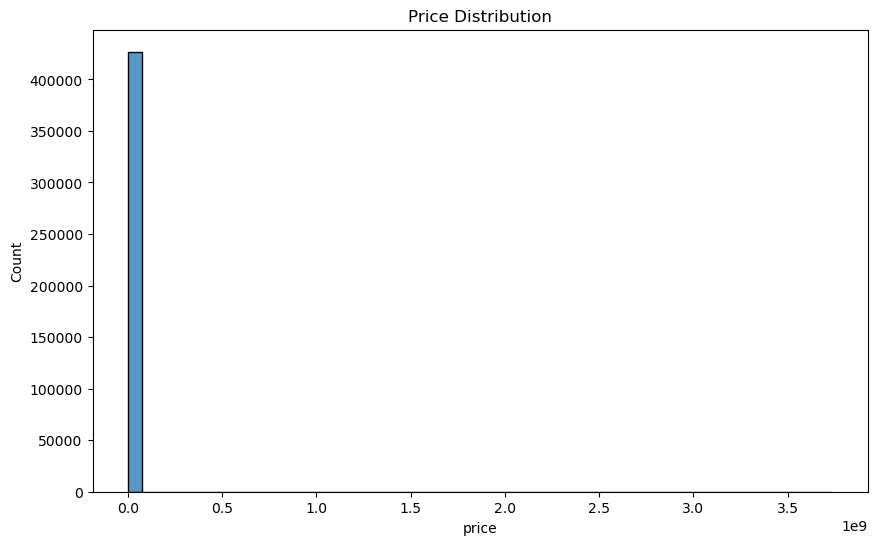

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of price
plt.figure(figsize=(10, 6))
sns.histplot(cars['price'], bins=50)
plt.title('Price Distribution')
plt.show()

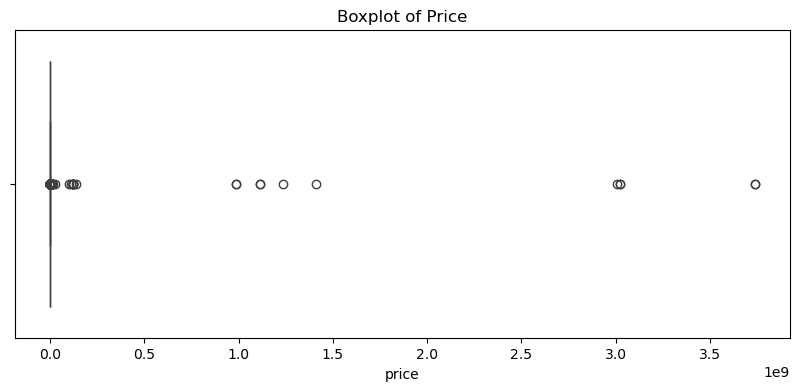

In [30]:
# Box plot of price
plt.figure(figsize=(10, 4))
sns.boxplot(x=cars['price'])
plt.title('Boxplot of Price')
plt.show()

In [33]:
# Count cars with price >= $1,000,000
million_plus = cars[cars['price'] >= 1_000_000]

million_plus.shape[0]

60

In [36]:
# Count cars with price < $500
below_100 = cars[cars['price'] < 500]

below_100.shape[0]

42094

In [42]:
# We can work with percentiles as well
low = cars['price'].quantile(0.01)
high = cars['price'].quantile(0.99)

low, high

(np.float64(0.0), np.float64(66995.0))

In [45]:
# Count cars with price = 0.0
million_plus = cars[cars['price'] == 0.0]

million_plus.shape[0]

32895

#### 4. Missing Values Analysis

In [8]:
# Percentage of missing values per column
missing = cars.isna().mean().sort_values(ascending=False)
missing

size            0.717675
cylinders       0.416225
condition       0.407852
VIN             0.377254
drive           0.305863
paint_color     0.305011
type            0.217527
manufacturer    0.041337
title_status    0.019308
model           0.012362
odometer        0.010307
fuel            0.007058
transmission    0.005988
year            0.002823
id              0.000000
region          0.000000
price           0.000000
state           0.000000
dtype: float64

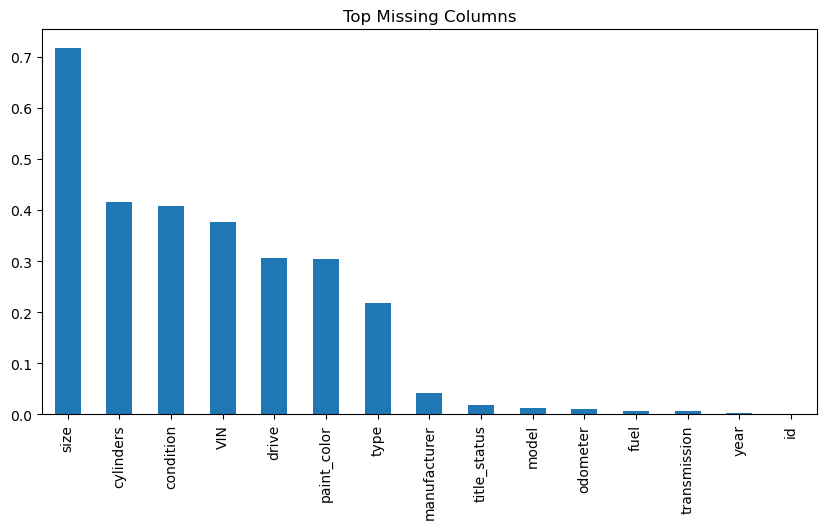

In [9]:
# Visualize missing values (top columns)
missing.head(15).plot(kind='bar', figsize=(10, 5))
plt.title('Top Missing Columns')
plt.show()

#### 5. Categorical Feature Exploration

In [49]:
# Manufacturer distribution
cars['manufacturer'].value_counts()

manufacturer
ford               70985
chevrolet          55064
toyota             34202
honda              21269
nissan             19067
jeep               19014
ram                18342
gmc                16785
bmw                14699
dodge              13707
mercedes-benz      11817
hyundai            10338
subaru              9495
volkswagen          9345
kia                 8457
lexus               8200
audi                7573
cadillac            6953
chrysler            6031
acura               5978
buick               5501
mazda               5427
infiniti            4802
lincoln             4220
volvo               3374
mitsubishi          3292
mini                2376
pontiac             2288
rover               2113
jaguar              1946
porsche             1384
mercury             1184
saturn              1090
alfa-romeo           897
tesla                868
fiat                 792
harley-davidson      153
ferrari               95
datsun                63
aston-martin

In [12]:
# Condition distribution
cars['condition'].value_counts()

condition
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64

In [13]:
# Fuel type
cars['fuel'].value_counts()

fuel
gas         356209
other        30728
diesel       30062
hybrid        5170
electric      1698
Name: count, dtype: int64

#### 6. Relationship Between Features and Price

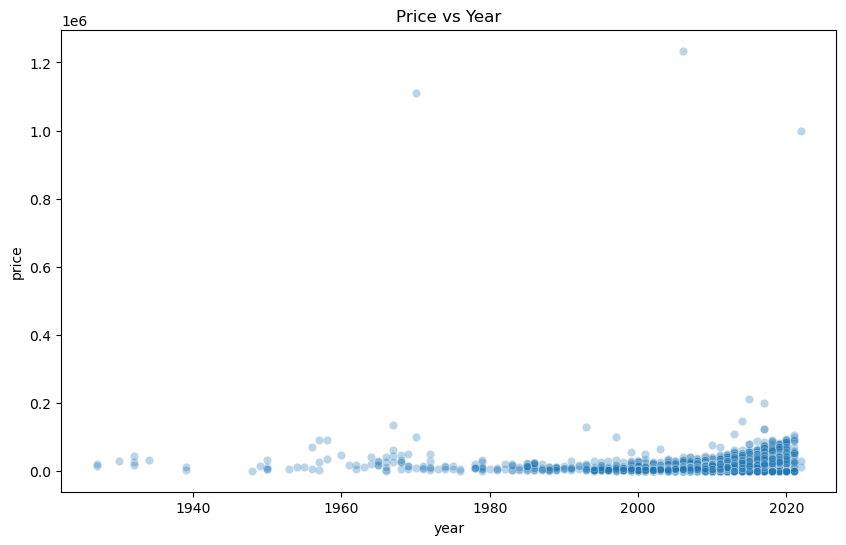

In [165]:
# Some preliminary plots
# Price vs Year 
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cars.sample(5000, random_state=42),
                x='year', y='price', alpha=0.3)
plt.title('Price vs Year')
plt.show()

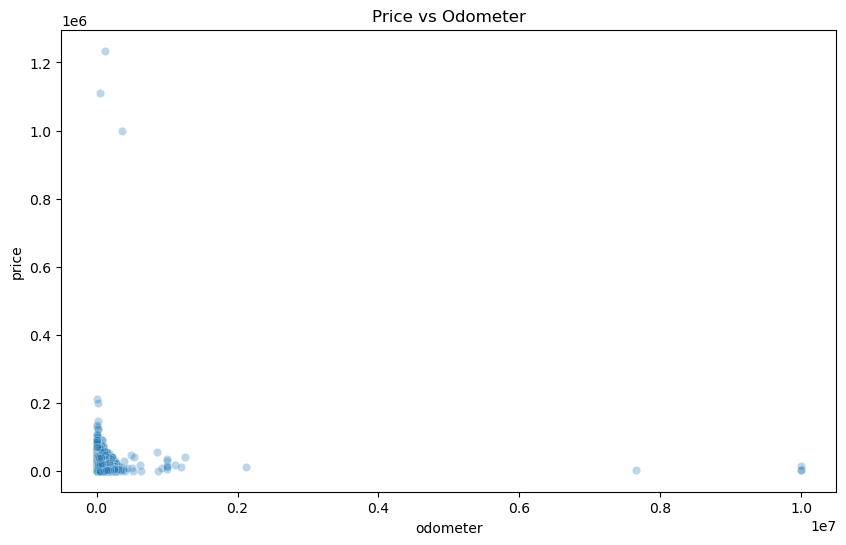

In [166]:
# Price vs Odometer
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cars.sample(5000, random_state=42),
                x='odometer', y='price', alpha=0.3)
plt.title('Price vs Odometer')
plt.show()

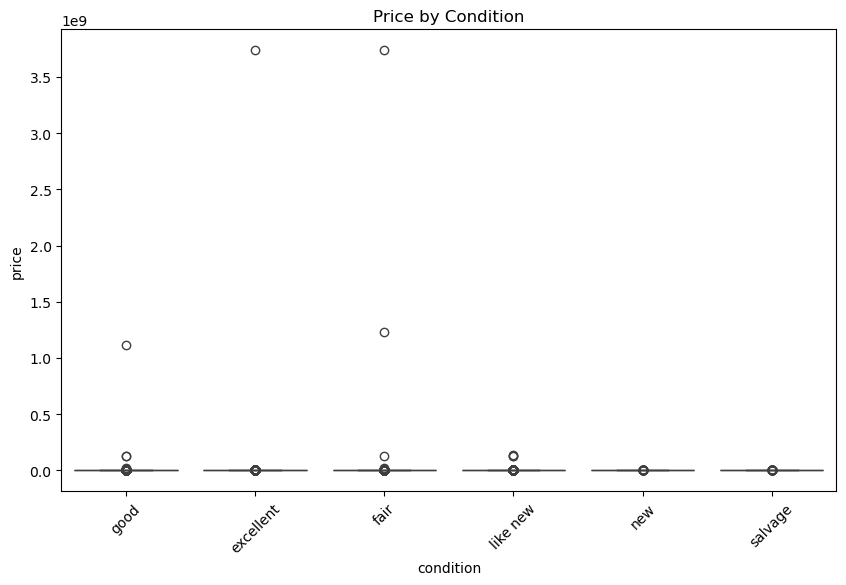

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=cars, x='condition', y='price')
plt.xticks(rotation=45)
plt.title('Price by Condition')
plt.show()

#### 7. Detect Data Quality Issues

In [18]:
# Check invalid prices
cars.query('price <= 0').shape

(32895, 18)

In [19]:
# Check invalid years
cars.query('year < 1900').shape

(0, 18)

In [20]:
# Check invalid odometer reads 
cars.query('odometer < 0').shape

(0, 18)

In [167]:
# Check for fuplicate entries
cars.duplicated().sum()

np.int64(0)

In [24]:
# Check for unique values
cars.nunique().sort_values(ascending=False)

id              426880
VIN             118246
odometer        104870
model            29649
price            15655
region             404
year               114
state               51
manufacturer        42
type                13
paint_color         12
cylinders            8
condition            6
title_status         6
fuel                 5
size                 4
transmission         3
drive                3
dtype: int64

#### 8. Initial Observations
1. The dataset contains a mix of numerical and categorical features
2. The price variable is highly skewed, with extreme outliers.
3. Several columns contain significant missing values, which may require removal.
4. Key variables such as year, odometer, and condition appear strongly related to price.
5. Some data quality issues exist, including: \
    5.1 Unrealistic price values (e.g., less than 0, 0, or extremely high (luxury)) \
    5.2 Potential outliers in mileage and year 

## Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

#### 1. Remove Irrevant Columns

In [168]:
# Drop the id and VIN columns
cars_clean = cars.drop(columns=['id', 'VIN'], errors='ignore')

cars_clean.head(20)

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
0,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc
5,hudson valley,1600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
6,hudson valley,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
7,hudson valley,15995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
8,medford-ashland,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,or
9,erie,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pa


#### 2. Remove or Replace Missing Data
Since there are many missing values (NaNs), we may remove or replace those values as follows (which are the only possibilities based on our Missing Value Analysis above: \
a) Drop columns with very high missing values (> 40–50%) \
b) Replace moderate missing (20–40%) with 'unknown'. The advantage of this approach is in addition to preserving the data, “unknown” becomes a category that works well with OneHotEncoder. \
c) Replace low missing (<5%) values with the most frequyenct value in that category.

In [169]:
# Drop columns high missing (> 40–50%) values (size and cylinders)
cars_clean = cars_clean.drop(columns=['size', 'cylinders'])

In [170]:
# Replace moderate missing values (20-40%) with 'unknown'
cols_fill_unknown = ['condition', 'drive', 'paint_color', 'type']
cars_clean[cols_fill_unknown] = cars_clean[cols_fill_unknown].fillna('unknown')

In [171]:
# Replace low missing (< 5%) with mode (for categorical data) and with median (for numerical data)
cols_mode = ['manufacturer', 'title_status', 'model', 'fuel', 'transmission']
for col in cols_mode:
    cars_clean[col] = cars_clean[col].fillna(cars_clean[col].mode()[0])

cars_clean['odometer'] = cars_clean['odometer'].fillna(cars_clean['odometer'].median())
cars_clean['year'] = cars_clean['year'].fillna(cars_clean['year'].median())

In [172]:
# Check the cleaned data
cars_clean.isna().mean().sort_values(ascending=False)

region          0.0
price           0.0
year            0.0
manufacturer    0.0
model           0.0
condition       0.0
fuel            0.0
odometer        0.0
title_status    0.0
transmission    0.0
drive           0.0
type            0.0
paint_color     0.0
state           0.0
dtype: float64

#### 3. Remove Invalid Data
Invalid numerical data include \
a) Zero or negative price \
b) Year smaller than 1900 or larger than 2026 (since we are in 2026, a 2027 car, for example, cannot be a used car) \
c) Negative odometer 

We will remove these data.


In [173]:
# Check percentage of cars with zero price—there seems to be many but it turns out to be a small percentage
zero_count = (cars['price'] == 0).sum()
total = len(cars)

zero_count, zero_count / total

(np.int64(32895), np.float64(0.07705912668665667))

In [174]:
# Remove invalid price values
zero_price_df = cars_clean[cars_clean['price'] == 0].copy() # Store rows with zero price for later use; we will predcit these prices once the model is ready
cars_clean = cars_clean[cars_clean['price'] > 0]

# Remove invalid odometer values
cars_clean = cars_clean[cars_clean['odometer'] >= 0]

# Remove unrealistic years
cars_clean = cars_clean[(cars_clean['year'] >= 1900) & (cars_clean['year'] <= 2025)]

**Note:** Rows with a price of zero were separated and saved. These rows are excluded from model training to avoid bias, but are retained in a separate dataset. After training the model, predicted prices can be generated for these observations, allowing the recovery of missing price information. **We will apply Steps 4–7 below to this separated dateset before any prediction.**

#### 4. Handle Outliers
After removing invalid data, extreme values (outliers) need to be handled to improve data quality. Outliers include \
a) Outliers in 'price' and 'odometer' are removed based on percentile thresholds to reduce the influence of extreme values. \
b) Outliers in 'year' (older than 1990) are filtered out based on common sense, as they do not represent the typical used car market. \
These steps help ensure that the dataset is both realistic and suitable for modeling.


In [175]:
low = cars_clean['price'].quantile(0.01)
high = cars_clean['price'].quantile(0.99)

cars_clean = cars_clean[(cars_clean['price'] >= low) & (cars_clean['price'] <= high)]

In [176]:
low_od = cars_clean['odometer'].quantile(0.01)
high_od = cars_clean['odometer'].quantile(0.99)

cars_clean = cars_clean[(cars_clean['odometer'] >= low_od) & (cars_clean['odometer'] <= high_od)]

In [177]:
cars_clean = cars_clean[(cars_clean['year'] >= 1990)]

#### 5. Convert Categorical Data to Lower Case

This step is necessary before the next step (removing duplicate entries). Categorical variables were standardized by converting all text to lowercase and removing leading/trailing whitespace. This step ensures consistency across categories (e.g., "Ford" and "ford") and improves the accuracy of duplicate detection.

In [178]:
# Select only object (string) columns
cat_cols = cars_clean.select_dtypes(include='object').columns

# Standardize text
cars_clean[cat_cols] = cars_clean[cat_cols].apply(
    lambda col: col.str.lower().str.strip()
)

#### 6. Remove Duplicate Records

In [179]:
# Check number of duplicate rows
cars_clean.duplicated().sum()

np.int64(46355)

In [180]:
# Remove duplicate rows
cars_clean = cars_clean.drop_duplicates()

#### 7. Log Transformation of Price
Since price seems to be skewed (based on the plots of price vs. odometer and price vs. year), we create a column that is the log of price.

In [181]:
import numpy as np
cars_clean['log_price'] = np.log(cars_clean['price'])

#### 8. Some Sanity Check

In [182]:
cars_clean.describe()

,price,year,odometer,log_price
count,321432.000000,321432.000000,321432.000000,321432.000000
mean,18810.644902,2012.298212,91860.514734,9.500954
std,13421.640681,5.846184,61214.637931,0.963679
min,150.000000,1990.000000,15.000000,5.010635
25%,7600.000000,2009.000000,38036.000000,8.935904
50%,15990.000000,2014.000000,86000.000000,9.679719
75%,27990.000000,2017.000000,135139.500000,10.239603
max,68747.000000,2022.000000,280000.000000,11.138188


In [183]:
cars_clean.isna().sum()

region          0
price           0
year            0
manufacturer    0
model           0
condition       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
paint_color     0
state           0
log_price       0
dtype: int64

## Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

While our exploratory data analysis (initial plots) provided some initial insights into relationships between variables and price, it does not account for interactions between multiple features. Regression modeling is needed to quantify the effect of each variable on price while controlling for other factors. This allows for a more precise understanding of the key drivers of used car prices, which is essential for making informed business recommendations.

Here are the steps we take toward modeling:

#### 1. Define Target and Features 
We use log_price as our target feature

In [184]:
# Target
y = cars_clean['log_price']

# Features (drop price + log_price)
X = cars_clean.drop(columns=['price', 'log_price'])

#### 2. Split Data to Train-Test

In [185]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### 3. Split Columns to Numerical and Categorical

In [186]:
numeric_features = ['odometer', 'year']
categorical_features = [col for col in X.columns if col not in numeric_features]

#### 4. Build Preprocessing Pipelines

In [187]:
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (categorical_transformer, categorical_features)
)

#### 5. Building Models

We will compare the following models and pick the best one for further refinement: \
a) Linear Regression \
b) Ridge \
c) Lasso

##### 5.1. Build and Evaluate Linear Regression

In [188]:
# Linear Regression
from sklearn.linear_model import LinearRegression

linreg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linreg_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('pipeline-1', ...), ('pipeline-2', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [143]:
# Evaluate the Linear Regression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

linreg_preds = linreg_pipe.predict(X_test)

linreg_rmse = np.sqrt(mean_squared_error(y_test, linreg_preds))
linreg_r2 = r2_score(y_test, linreg_preds)

linreg_rmse, linreg_r2

(np.float64(0.5736849385189314), 0.6450245755251343)

##### 5.2. Build and Evaluate Ridge

In [189]:
# Build Ridge
from sklearn.linear_model import Ridge

ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('pipeline-1', ...), ('pipeline-2', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [146]:
# Evaluate Ridge
ridge_preds = ridge_pipe.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
ridge_r2 = r2_score(y_test, ridge_preds)

ridge_rmse, ridge_r2

(np.float64(0.5702657777769876), 0.6492432714549066)

##### 5.3. Build and Evaluate Lasso

In [190]:
# Build Lasso
from sklearn.linear_model import Lasso

lasso_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=10000))
])

lasso_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('pipeline-1', ...), ('pipeline-2', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [148]:
# Evaluate Lasso
lasso_preds = lasso_pipe.predict(X_test)

lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_preds))
lasso_r2 = r2_score(y_test, lasso_preds)

lasso_rmse, lasso_r2

(np.float64(0.9628850792559286), -7.021983075006233e-07)

#### 6. Compare Models

In [191]:
model_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'RMSE': [linreg_rmse, ridge_rmse, lasso_rmse],
    'R2': [linreg_r2, ridge_r2, lasso_r2]
})

model_results.sort_values('RMSE')

,Model,RMSE,R2
1,Ridge Regression,0.570266,6.492433e-01
0,Linear Regression,0.573685,6.450246e-01
2,Lasso Regression,0.962885,-7.021983e-07


#### 7. Model Comparison and Selection
Three models were evaluated: Linear Regression, Ridge, and Lasso. Ridge and Linear Regression performed similarly, with Ridge achieving slightly better RMSE and R². Lasso performed significantly worse, indicating that aggressive feature selection is not suitable for this dataset. Therefore, Ridge Regression is selected as the final model due to slighlty better RMSE and R², its stability, and its known ability to handle multicollinearity among features, due to the use of one-hot encoding for categorical variables—with many one-hot encoded categories and related numeric features, multicollinearity is expected. Ridge is well-suited here because it keeps all features while controlling their influence through regularization.

We now proceed to making sure Ridge is a stable and reliable model by evaluating its performance across multiple folds of the data (Step 8) and then fine-tune the Ridge model by selecting the optimal value of the regularization parameter ($\alpha$) using cross-validation (Step 9). Step 9 improves model generalization and ensures the best balance between bias and variance.

#### 8. Cross Validation for Ridge

In [192]:
from sklearn.model_selection import cross_val_score

ridge_cv_scores = cross_val_score(
    ridge_pipe,
    X_train,
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=5
)

ridge_cv_rmse = -ridge_cv_scores.mean()

ridge_cv_rmse

np.float64(0.572846634258201)

It is observed that the RMSE obtained from cross-validation (0.5728) is very close to the RMSE on the test set (0.5703), indicating that the Ridge model generalizes well to unseen data. This suggests that the model is not overfitting and that its performance is stable across different subsets of the data.

#### 9. GridSearchCV for Ridge

In [193]:
from sklearn.model_selection import GridSearchCV

ridge_params = {
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipe,
    ridge_params,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

ridge_grid.best_params_, -ridge_grid.best_score_

({'model__alpha': 1}, np.float64(0.5728412927296752))

We observe that GridSearchCV identified an optimal $\alpha$ of 1 for the Ridge model. The corresponding cross-validation RMSE (0.57284) is alomost identical to the test RMSE, indicating that the model was already close to optimal before fine-tuning. This suggests that the dataset does not require heavy regularization and a moderate regularization (the default value of $\alpha$) is sufficient.

#### 10. Final Evaluation of the Model
We now evaluate the model performance by calculating the RMSE based on the data the model has never seen.

In [194]:
best_ridge = ridge_grid.best_estimator_

best_ridge_preds = best_ridge.predict(X_test)

best_ridge_rmse = np.sqrt(mean_squared_error(y_test, best_ridge_preds))
best_ridge_r2 = r2_score(y_test, best_ridge_preds)

best_ridge_rmse, best_ridge_r2

(np.float64(0.5702657777769876), 0.6492432714549066)

We observe that the tuned Ridge model achieves an RMSE of approximately 0.57 and an R² of 0.65 on the test set. The RMSE is very close to the cross-validation RMSE (0.5728), indicating strong generalization and no evidence of overfitting. The R² value suggests that the model explains a substantial portion of the variation in used car prices, demonstrating that the selected features capture meaningful drivers of price.

#### 11. Overall Evaluation of the Model
The objective of this project was to identify the key factors that influence used car prices and provide actionable insights for a dealership. The Ridge Regression model achieved an RMSE of approximately 0.57 and an R² of 0.65 on the test set, indicating that the model explains a substantial portion of price and performs well on unseen data. The close alignment between cross-validation RMSE and test RMSE further confirms that the model generalizes well and is not overfitting.

From a modeling perspective, Ridge Regression proved to be the most appropriate choice. Linear Regression performed similarly but lacked regularization, while Lasso Regression underperformed, suggesting that retaining all features is more suitable for this dataset.

From a business perspective, the model is sufficiently accurate to provide meaningful directional insights into pricing drivers. While it may not predict prices perfectly, it reliably captures the relative importance of features such as vehicle age, mileage, condition, and type.

#### 12. Limitations and Considerations
1. The model explains about 65% of price variation, indicating that some factors (e.g., local market conditions, vehicle history, or unobserved features) are not captured.
2. One-hot encoding introduces many correlated features, which can complicate interpretation.
3. The dataset required significant cleaning, which may limit representativeness.

## Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

First, we look at the coeffcients found by the Ridge model:

In [195]:
import numpy as np
import pandas as pd

# Get OneHotEncoder
ohe = best_ridge.named_steps['preprocessor']\
    .named_transformers_['pipeline-2']\
    .named_steps['ohe']

# Get feature names
categorical_names = ohe.get_feature_names_out(categorical_features)
feature_names = np.concatenate([numeric_features, categorical_names])

# Get coefficients
coefs = best_ridge.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs
})

# Sort by absolute impact
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df_sorted = coef_df.sort_values('abs_coef', ascending=False)

# Since there are too many coeffcients, we only look at the ones that are more meaningful
# Filter relevant feature groups
relevant_prefixes = [
    'type_',
    'condition_',
    'fuel_',
    'transmission_',
    'year',
    'odometer'
]

relevant_coefs = coef_df[
    coef_df['feature'].str.startswith(tuple(relevant_prefixes))
].copy()

# Separate numeric and categorical features
coef_df[coef_df['feature'].isin(['year', 'odometer'])]

# Clean feature names
relevant_coefs['feature'] = relevant_coefs['feature'].str.replace('_', ' ')

relevant_coefs.sort_values('abs_coef', ascending=False).head(20)

,feature,coefficient,abs_coef
21259,condition salvage,-0.613784,0.613784
21255,condition fair,-0.452437,0.452437
1,year,0.382086,0.382086
21261,fuel diesel,0.322124,0.322124
21254,condition excellent,0.273909,0.273909
21257,condition like new,0.272910,0.272910
21260,condition unknown,0.232010,0.232010
0,odometer,-0.213144,0.213144
21256,condition good,0.143966,0.143966
21258,condition new,0.143424,0.143424


#### 1. Key Drivers of Used Car Prices
The coefficients of the Ridge model were analyzed to identify the most influential factors affecting used car prices. Since the model was trained on the logarithm of price, the coefficients represent directional impact (increase or decrease in price), with larger absolute values indicating stronger influence.

##### 1.1 Condition
Vehicle condition is one of the strongest drivers of price: \
$-$ Cars in salvage and fair condition have significantly lower prices. \
$-$ Cars in excellent or like new condition are associated with higher prices.

This confirms that vehicle condition is a critical determinant of value in the used car market.

##### 1.2. Age and Mileage
$-$ Year (positive coefficient): newer vehicles tend to have higher prices. \
$-$ Odometer (negative coefficient): higher mileage reduces price.

These results align with expectations that newer, less-used vehicles command higher value.

##### 1.3. Fuel Type
$-$ Diesel vehicles are associated with higher prices. \
$-$ Hybrid and electric vehicles show negative coefficients in this dataset.

This suggests that, within this dataset, diesel vehicles may be perceived as more valuables.

##### 1.4. Vehicle Type
$-$ Pickup trucks and off-road vehicles are associated with higher prices. \
$-$ Buses, minivans, and SUVs tend to have lower relative prices.

This indicates that vehicle type plays an important role in pricing, with certain categories (e.g., trucks) being more valuable in the market.

##### 1.5. Transmission
Automatic transmission has a slight negative effect relative to the baseline. This is counterintuitive, because manual transmission is expected to bring the price lower. However, we should note that transmission type has a very small influence overall.

#### 2. Summary Insight
Overall, the most important drivers of used car prices are:

1. Condition
2. Vehicle age (year)
3. Mileage (odometer)
4. Fuel type
5. Vehicle type

These findings provide clear, actionable insights into what features contribute most to vehicle value.

#### 3. Conclusion
Overall, the model meets the business objective by providing a reliable and interpretable framework for understanding what drives used car prices. The insights derived from this model can support better inventory selection and pricing strategies for the dealership.

## Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

Based on the analysis and modeling results, several key factors were identified that influence used car prices. These insights can be translated into actionable strategies to help dealerships optimize inventory selection and pricing.

##### 1. Prioritize Vehicle Condition
Vehicle condition is the strongest driver of price. Cars in '*excellent*' or '*like new*' conditions command significantly higher prices. Cars in '*fair*' or '*salvage*' conditions are heavily discounted. It is recommended that dealershipd focus on acquiring and selling vehicles in good or better conditions, as they offer higher resale value and profitability. Avoid investing heavily in low-condition vehicles unless priced significantly below market.

##### 2. Stock Newer, Lower-Mileage Vehicles
Newer cars (higher year) are more valuable while higher mileage (odometer) significantly reduces price. It is recomended that dealerships prioritize inventory with recent model years and lower mileage. These vehicles are more attractive to buyers and can be priced at a premium.

##### 3. Focus on High-Value Vehicle Types
Pickup trucks and off-road vehicles tend to have higher prices. Minivans, buses, and some SUVs tend to have lower relative value. Therefore, dealerships are recommended to increase their inventory of pickup trucks and off-road vehicles. They should, however, be more selective when stocking minivans and lower-demand vehicle types.

##### 4. Consider Fuel Type Carefully
Diesel vehicles are associated with higher prices while hybrid and electric vehicles do not consistently show price premiums in this dataset. It is recommended that dealerships increase their inventory of diesel vehicles, but evaluate local demand carefully before investing heavily in hybrid or electric vehicles.

##### 5. Transmission Has Limited Impact
Transmission type has a relatively small effect compared to other factors. So, dealerships should not prioritize inventory decisions based heavily on transmission type alone.

##### 6. Overall Strategy
To maximize profitability and competitiveness, dealerships should:
1. Stock newer, low-mileage vehicles in good condition
2. Prioritize high-demand vehicle types (e.g., trucks)
3. Be cautious with low-condition or high-mileage vehicles
4. Use pricing strategies that reflect these key value drivers

### Conclusion
The model provides a reliable and interpretable framework for understanding used car pricing. While it does not capture all possible factors, it successfully identifies the most important drivers of value. These insights can support more informed inventory decisions and pricing strategies, helping dealerships improve overall performance and profit.